# EDA con datos médicos & ML de arboles de decisión

**EDA PARA ML**

## Paso 0: **Setup básico: Imports & Read data**

> (1) **Importar librerías necesarias**  
>  
> (2) **Data Inical**  

### (1) **Importar librerías necesarias**  
> - pandas para cargar nuestros datos  
> - matplotlib y seaborn para crear graficos 
> - sklearn para realizar ML:  
>    . sklearn.model_selectio para train_test_split  
> . sklearn.preprocessing para StandardScaler, MinMaxScaler  
> . sklearn.preprocessing para LabelEncoder, OneHotEncoder, OrdinalEncoder  
> .sklearn.feature_selection para f_classif, SelectKBest  
>  * ML:  .pickle y .json para guardar los modelos 

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# split para modelado
from sklearn.model_selection import train_test_split, GridSearchCV

# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

# To save models
import json
import pickle

# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

### (2) **Data Inicial**

In [71]:
df = pd.read_csv("../data/raw/diabetes-data.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [72]:
df.info() # explorar datos

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Observaciones:**

> DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 768 filas y 9 columnas  
> * Los datos que aporta el datset son 9 columnas de tipo numérico (enteros y decimales)
> * ``dtypes``: float64(2), int64(7)

#### (2.1) **Definición del problema e información del conjunto de datos**

* **Planteamiento:** Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. 
* **Objetivo:** Predecir en base a medidas diagnósticas si un paciente tiene o no diabetes. Es importante tener en cuenta en este data-set que tratamos con datos médicos y no podemos inventar o elminar información que no este justificada ya que queremos obtener el minimo error en el resultado.

* **Varibales independientes**

COLUMNAS Y CARACTERÍSTICAS DE LAS VARIABLES

**1. NUMÉRICAS:**

> Continuas: Medicas  
        - `Glucose`. Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral a la glucosa (numérico)  
        - `BloodPressure`. Presión arterial diastólica (medida en mm Hg) (numérico)  
        - `SkinThickness`. Grosor del pliegue cutáneo del tríceps. Según el grosos de la piel podemos detectar el nivel de grasa (obesidad del paciente) que es una condición que puede influir en la diabetes (medida en mm) (numérico)  
        - `Insulin`. Insulina sérica de 2 horas (medida en mu U/ml). La insulina sérica es la insulina presente en la sangre. Si los niveles son bajos entonces indica déficit de produccion de glucosa por lo tanto puede tratarse de diabetes avanzada. La insulina es la hormonoa que regula la absorción de la glucosa, por eso cuando es baja se presdenta como síntoma de diabetes. (numérico)  
        - `BMI`. Índice de masa corporal(IMC), relación entre el peso y la altura del paciente (numérico)

> Discretas: Personas  
        - `Pregnancies`. Número de embarazos del paciente (numérico)  
        - `DiabetesPedigreeFunction`. Función de pedigrí de diabetes, es el historial genealógico o familiar que señala el riesgo hereditario. (numérico)  
        - `Age`. Edad del paciente (numérico)

**2. CATEGÓRICAS**  
No hay columnas con características categóricas

* **Variable target** 
> ``Outcome``, es la variable que nos da el resultado del planteamiento del problema, si un paciente es diabetico o no. No se indica el tipo de diabetes de la persona.

**Observaciones:**

> Por ahora se usan todas las columnas para el análisis ya que todas son importantes para determinar si el paciente tiene diabetes o no.

## Paso 1: **Limpieza de datos**

### (1) **Valores NaNs**

¿Hay valores NaN? ¿Dónde? ¿Representarían información importante para el análisis?  

In [73]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


> No existen valores nulos.

### (2) **Valores duplicados**

In [74]:
df.duplicated().sum()

np.int64(0)

> No tenemos valores duplicados.

### (3) **Valores a 0**

In [75]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

**OBSERVACIONES DE LOS VALORES A 0:**

> * Indica que 11 pacientes con han estado nunca embarazadas (Pregnancies                 111)  
> Glucose                       5  
> BMI                          11  
> BloodPressure                35  
>  
> * Las columnas con más valores a 0 son:    
> SkinThickness               227  
> Insulin                     374    
> 
> DiabetesPedigreeFunction      0  
> Age                           0  
>  
> * Columna target: El 0 representa que 500 pacientes  dUDA XXX si o no XXX tiene diabetes.  
> Outcome                     500

**CONCLUSIONES**

> * En las columnas con más valores a 0 son Insulin y SkinThickness. Concluimos que esos valores representan más de la mitad del dataset y es posible no se tomaron los datos durante las pruebas Para el análisis podríamos pasarlos a valores NaN sin necesidad de eliminar las columnas pero no la utilizaría para el ML ya que representan alarededor de la mitad de la data de valores nulos.  
>  
> * Elimino las filas que contienen el valor zero en las dos últimsa columnas mencionadas y también las filas a 0 de la columna BloodPressure ya que es imposible en un ser humano si la persona está viva, por eso la columna Glucosa y BMI adquieren mayor importancia



In [76]:
df = df.drop(df[(df['BMI'] == 0) & (df['Glucose'] == 0) & (df['BloodPressure'] == 0)].index)

In [77]:
df = df.drop(['SkinThickness', 'Insulin'], axis=1)

In [78]:
df.shape

(768, 7)

In [79]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
       'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

**OBSERVACIONES DESPUES DE LA LIMPIEZA DE DATOS:**

* **Columnas con mayor importancia:** Glucose, Age, BMI, Pregnancies y DiabetesPedigreeFunction. 
> 
>* ``BMI``, niveles altos indican mayor resistencia a la insulina y diabetes de     tipo 2 (índice de masa corporal). En el gráfico los valores se acumulan entre el 21 y 40  
> Según rangos estándar OMS, a partir del 30 oo más se considera obesidad y este si es un factor que aumenta el reisgo a ser diabetico
> 
>  * ``BloodPressure``, relacionado con BMI, la resistencia a la insulina            (absorción baja de glucosa) aumenta los niveles de presión arterial.  
> * ``Pregnancies``, los emabrazos puedes aumentar el riesgo de desarrollar diabetes tipo 2 en el futuro. La mayoria de las personas sí han estado embarazadas  
> * ``DiabetesPedigreeFunction``, riesgo genético de tener diabetes. Hay más concentración de datos en las personas que están diagnosticadas sin la enfermedad tienen indices entre el 0.20 y 0.40

 * **Nueva variable target** 
> * ``Glucose``, los resultados de un test de tolerancia a la glucosa determinan si un paciente es diabetico o prediabetico. La mayor concentración de data esta entre el 80-130.  
 La mayoria de los diagnosticados sin diabetes según los rangos de glucosa podrían ser prediabeticos ya que lo normal sería menos de 100 de glucosa en sangre

## Paso 3: Análisis de Variables

> (1) **Descripción de columnas utilizadas para el análisis**   
> (2) **Análisis de Variables Numéricas:**  
> Tipos de análisis: Univariante & Multivariante    
> (3) **Análisis de Variables Categóricas,**  
> Tipos de análisis: Univariante & Multivariante   

### (2) **Análisis de Variables Numéricas:**


In [80]:
# Gráficos
# Separo las variables en grupo 
medical_conditions = ['DiabetesPedigreeFunction', 'Glucose', 'BloodPressure', 'BMI']
person_id_vars = ['Pregnancies', 'Age']

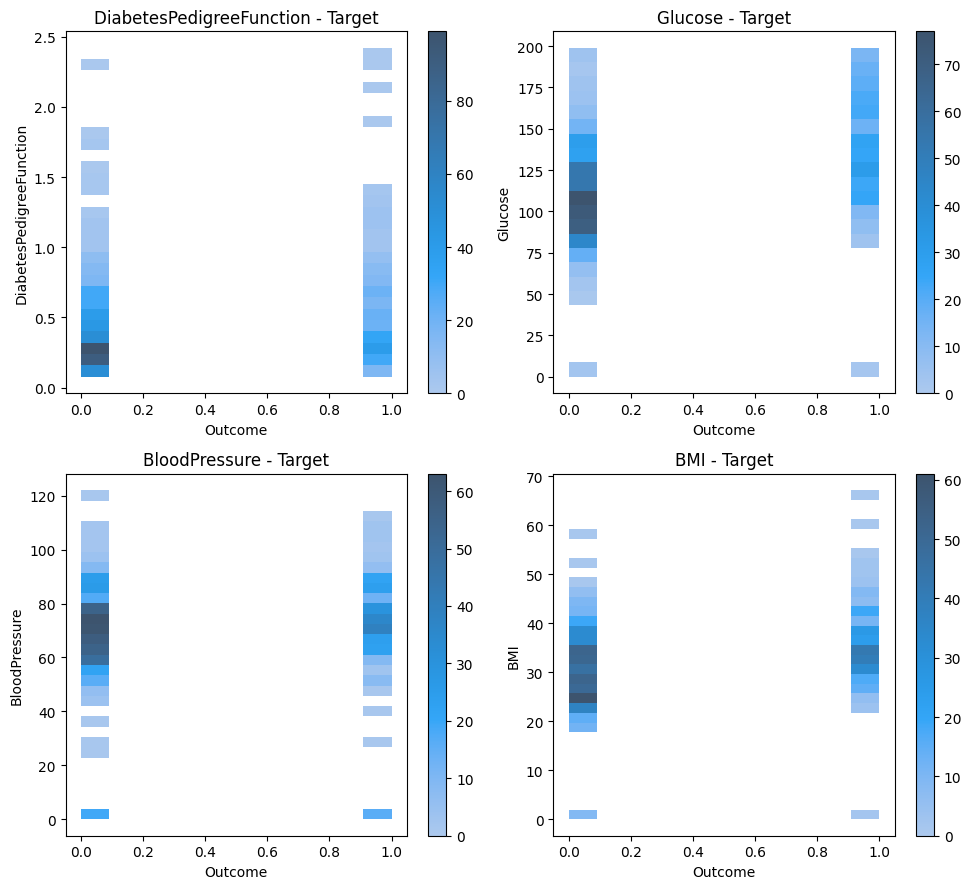

In [81]:
# La barra lateral represnta el conteo de datos con parámetro 'cbar'
import math 
# Gráficos para la información médica
n = len(medical_conditions)
cols_grid = 2                         
rows = math.ceil(n / cols_grid)   # math.ceil() calcula una divisón  y redondea a un numero entero
fig, axis = plt.subplots(rows,cols_grid, figsize=(10, 9))
axis = axis.flatten()
for i, columna in enumerate(medical_conditions):
    sns.histplot(data=df, x="Outcome", y=columna, cbar=True,
        ax=axis[i]
    )
    axis[i].set_title(f"{columna} - Target")

plt.tight_layout()
plt.show()


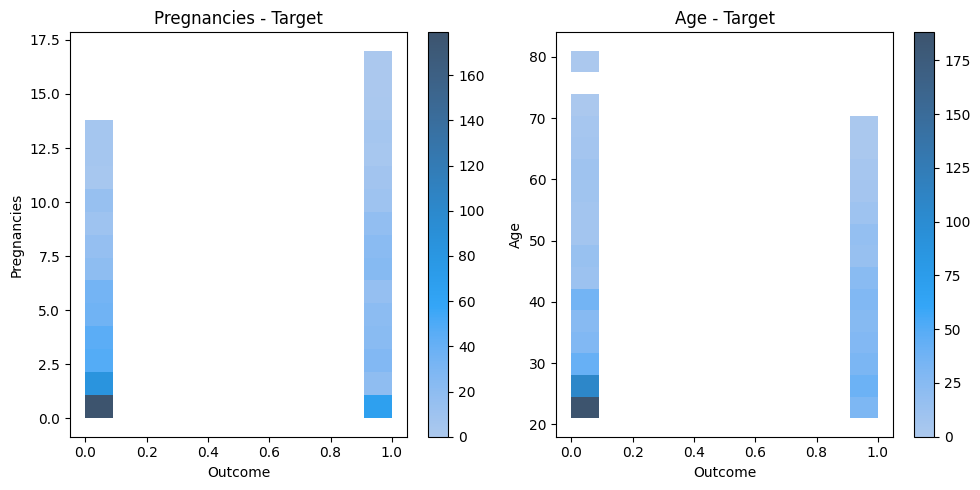

In [82]:
# Gráficos para la información personal
fig, axis = plt.subplots(1, 2, figsize=(10, 5))   

for i, columna in enumerate(person_id_vars):          
    sns.histplot(data=df, x="Outcome", y=columna, cbar=True, ax=axis[i])
    axis[i].set_title(f"{columna} - Target")

plt.tight_layout()
plt.show()

**Observaciones:**
* ``Pregnancies``, los emabrazos puedes aumentar el riesgo de desarrollar diabetes tipo 2 en el futuro. La mayoria de las personas sí han estado embarazadas
 
* ``DiabetesPedigreeFunction``, riesgo genético de tener diabetes. Hay más concentración de datos en las personas que están diagnosticadas sin la enfermedad tienen indices entre el 0.20 y 0.40

### (3) **Correlaciones**


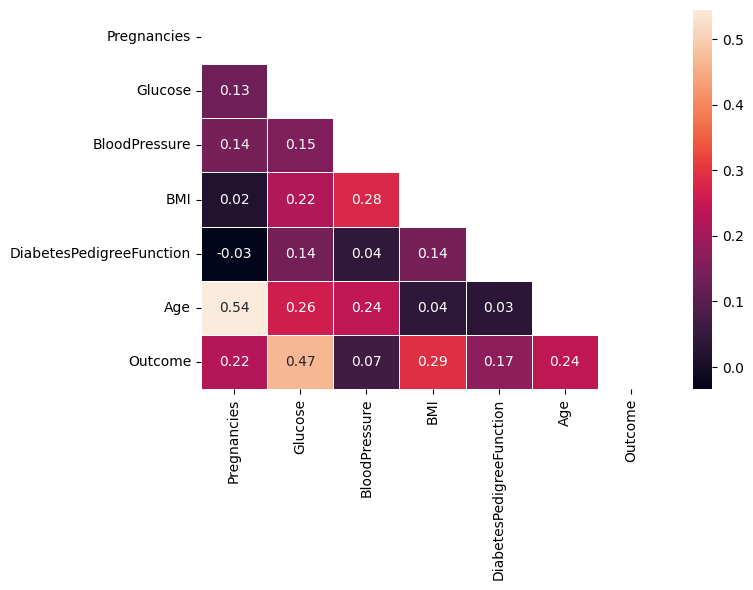

In [83]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**CONCLUSIONES CAMBIAAR REPASAR!:**
* La columna más relacionada con el target es la Glucosa seguida del peso corporal de la persona

In [84]:
#imports
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
X_train, y_train, X_test
# Split data TRaing& Test
X_train,X_test,y_train,y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

mi_prediccion = (X_test['Glucose'] > 120).astype(int)
# ARMAR PLT TRE DESICION
# plt.figure(figsize=(12,12))
# tree.plot_tree(clf, 
#                feature_names=["viento",
#                               "clima_nublado","clima_soleado",
#                               "temperatura_fresco", "temperatura_templado",
#                               "olas_pocas"],  
#                class_names=["no","si"],
#                filled=True);

NameError: name 'sklearn' is not defined

## PASO 4: INGENIERIA CARACTERISTICAS:_ OUTLIERS 

## PASO 5: GUARDADO DE LA DATA

In [ ]:
# Saving processed data
df.to_csv("../data/processed/diabetes_eda.csv", index=False)

# **ML Arboles de decisión**

*  A los algoritmos de ML le gustan los vectores

Para que cada fila sea un vector no debe tener valores nulos y cada celda debe ser un numero y no un texto o fecha u otra cosa que no sea un numero. Entonces deberemos:

1. Eliminar o imputar nulos en el EDA
2. Eliminar o transformar en numeros las celdas que no son numeros.
3. Con los algoritmos de arboles de decisoines no es necesario ormalizar la data, además en este proyecto no tenemos ninguna varibale categórica. Sin embaego, en algoritmos como knn, regresion y redes neuronales es bueno aplicar transformaciones de normalizacion a las columnas numericas. 

## Paso 1: Imports

- pandas para cargar nuestros datos
- sklearn para realizar el ML
- matplotlib y seaborn para graficos

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Paso 2: Lectura del conjunto

In [ ]:
df = pd.read_csv('../data/processed/diabetes_eda.csv')
df

## PASO 3: Split data 

Definimos cual es la columna a predecir y que columnas utilizaremos como predictoras.


Esta separacion deberia hacerse al principio antes de la imputacion de nulos y la transformacion de los datos pero por simplicidad haremos esta pequeña trampa de hacerlo luego.

In [ ]:
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [ ]:
X_train, y_train

,Pregnancies,Glucose,BloodPressure,BMI,DiabetesPedigreeFunction,Age
353,1,90,62,27.2,0.580,24
711,5,126,78,29.6,0.439,40
373,2,105,58,34.9,0.225,25
46,1,146,56,29.7,0.564,29
682,0,95,64,44.6,0.366,22
...,...,...,...,...,...,...
451,2,134,70,28.9,0.542,23
113,4,76,62,34.0,0.391,25
556,1,97,70,38.1,0.218,30
667,10,111,70,27.5,0.141,40


In [ ]:
X_test, y_test

## Paso 4: Modelado y ajuste 

In [90]:

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

## Paso 5: Análisis de variables

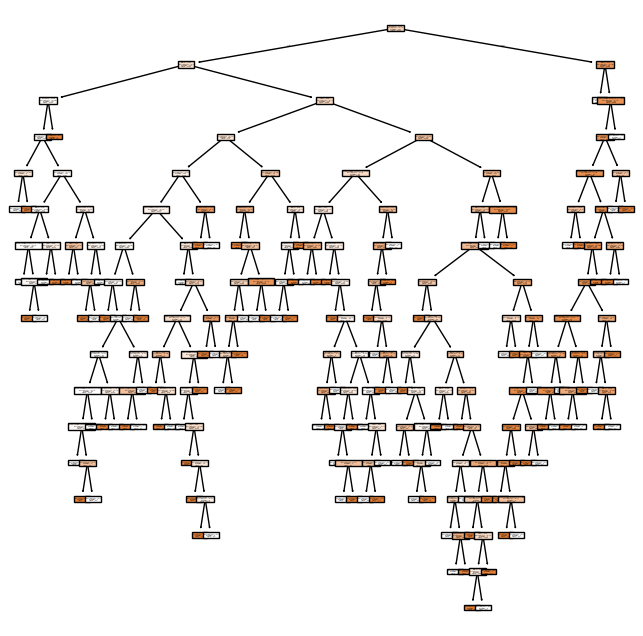

In [91]:
plt.figure(figsize=(8, 8))

tree.plot_tree(model,feature_names=list(X_train.columns),filled=True)
plt.show()


# TODO: definir class_names. Ex: class_names=["iris setosa", "iris versicolor", "iris virginica"],
plt.show()

## Paso 6: Predicción

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 1.,
       0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0.,
       1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
       1., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 0.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,
       0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
       0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0.])

### (1) **DataFrame comparativo entre las predicciones y la data de testeo**

In [94]:
pred_vs_real = pd.DataFrame()
pred_vs_real["y_test"] = y_test
pred_vs_real["predicciones"] = y_pred
pred_vs_real

,y_test,predicciones
44,0,0.0
672,0,0.0
700,0,0.0
630,1,0.0
81,0,0.0
...,...,...
32,0,0.0
637,0,0.0
593,0,0.0
425,1,1.0


## Paso 7: Métricas

In [93]:
from sklearn.metrics import accuracy_score

accuracy= accuracy_score(y_test, y_pred)
print("Accuracy Arbol:", accuracy)

Accuracy Arbol: 0.7012987012987013


OBSERVACIONES:

> x

## DUDA::: Utilizando la caja negra predictora seleccionada y creando reporte final con el conjunto de prueba (X_test,y_test)

Las metricas que obtengamos de este resultado seran las que comuniquemos en nuestro reporte final para decir que tan bien funciona el modelo predictivo que hemos seleccionado

In [98]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7012987012987013


In [99]:
matrix = confusion_matrix(y_test, y_pred)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy por clase: [0.83       0.46296296]


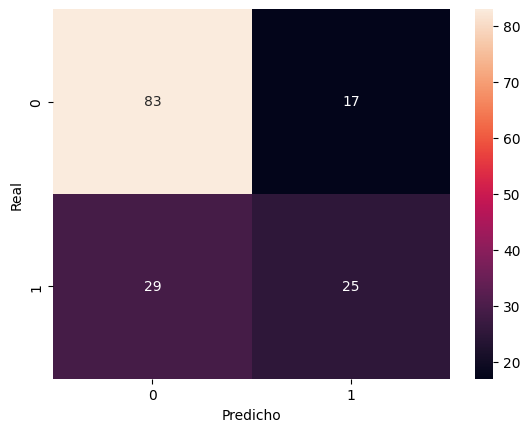

In [100]:
confussion_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

In [110]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mean_absolute = mean_absolute_error(y_test, y_pred)

report_squared_error = mse
report_absolute_error = mean_absolute
report_r2_varianza = r2

In [111]:
report_absolute_error, report_r2_varianza, report_squared_error

(0.2987012987012987, -0.3118518518518518, 0.2987012987012987)

**OBSERVACIONES:**


> Este resultado es bueno o es malo?
> 
> Como saber si mi prediccion es buena o mala?
> 
> - 90% de Accuracy (u otra metrica) es bueno?
> - 30% de Accuracy (u otra metrica) es malo?
> 
> Todo es relativo, cual es el accuracy actual en el negocio? Que se utiliza actualmente para hacer la prediccion? Podemos comparar contra eso? Lo mejoramos o no?
> 
> Lo mas recomendado es establecer una base, si el negocio ya la tiene podemos empezar por alli si no podemos utilizar la media o la moda como predictor base dependiendo si la variable a predecir es numerica o categorica respectivamente.

## Ejemplo de la moda como predictor base

Aqui utilizaremos los predictores Dummy de sklearn que nos permiten exactamente eso tener una base contra la cual comparar nuestros resultados

In [ ]:
predictor_base = sklearn.dummy.DummyClassifier(strategy='most_frequent')
predictor_base.fit(X_train, y_train);

In [ ]:
predicciones_base = predictor_base.predict(X_test)

In [ ]:
accuracy_base = sklearn.metrics.accuracy_score(y_test, predicciones_base)
print("Accuracy base:", accuracy_base)

Accuracy base: 0.8873512988589464


In [ ]:
matrix = sklearn.metrics.confusion_matrix(y_test, predicciones_base)
print("Accuracy por clase:", matrix.diagonal()/matrix.sum(axis=1))

Accuracy por clase: [1. 0.]


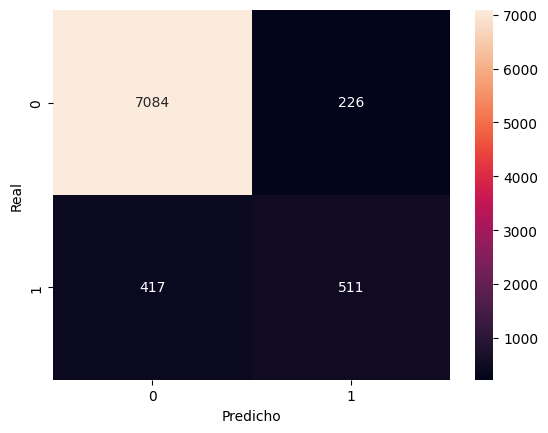

In [ ]:
confussion_matrix = sklearn.metrics.confusion_matrix(y_test, predicciones)
sns.heatmap(confussion_matrix, annot=True, fmt='g')
plt.xlabel('Predicho')
plt.ylabel('Real');

In [ ]:
report = sklearn.metrics.classification_report(y_test, predicciones_base)
print(report)

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      7310
         yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/vscode/.local/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
